In [112]:
import numpy as np
import pandas as pd

In [113]:
df= pd.read_csv('data.csv')
print(df.head())

   student_id  cgpa   iq placement
0           1   2.1   85        no
1           2   2.5   90        no
2           3   2.8   95        no
3           4   3.0  100       yes
4           5   3.2  105       yes


In [114]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   student_id  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    int64  
 3   placement   100 non-null    object 
dtypes: float64(1), int64(2), object(1)
memory usage: 3.3+ KB
None


In [115]:
df=df.drop('student_id',axis=1)
print(df.head())

   cgpa   iq placement
0   2.1   85        no
1   2.5   90        no
2   2.8   95        no
3   3.0  100       yes
4   3.2  105       yes


    cgpa   iq  placement
0    2.1   85          0
1    2.5   90          0
2    2.8   95          0
3    3.0  100          1
4    3.2  105          1
..   ...  ...        ...
95   3.3  111          1
96   2.1   82          0
97   3.6  120          1
98   3.2  107          1
99   2.7   93          0

[100 rows x 3 columns]


C:\Users\Taimoor Arshad\AppData\Local\Temp\ipykernel_14512\671146182.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["placement"]=df["placement"].replace({"yes":1,"no":0})


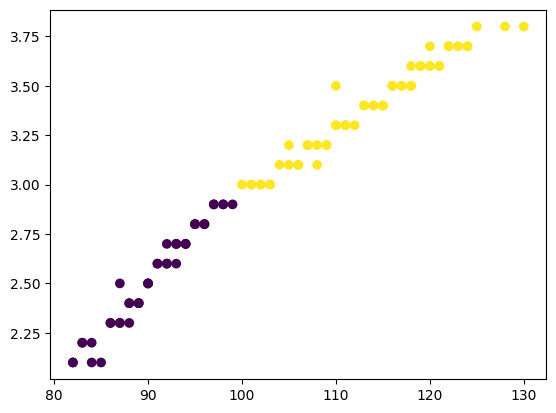

In [116]:
df["placement"]=df["placement"].replace({"yes":1,"no":0})
print(df)
import matplotlib.pyplot as plt

plt.scatter(df["iq"], df["cgpa"],c=df["placement"])


In [ ]:
X=df.iloc[:,0:2]   ##independent variable
y=df.iloc[:,-1]  ##dependent variable


    cgpa   iq
0    2.1   85
1    2.5   90
2    2.8   95
3    3.0  100
4    3.2  105
..   ...  ...
95   3.3  111
96   2.1   82
97   3.6  120
98   3.2  107
99   2.7   93

[100 rows x 2 columns]


In [124]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.1)  ## split the data into training and testing data. test_size is the percentage of data that will be used for testing. 0.1 means 10% of the data will be used for testing and 90% will be used for training.
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(90, 2)
(10, 2)
(90,)
(10,)


In [125]:
from sklearn.preprocessing  import StandardScaler

scaler= StandardScaler()

x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [131]:
from sklearn.linear_model import LogisticRegression

model= LogisticRegression()
model.fit(x_train,y_train)  ## fit the model to the training data

y_pred=model.predict(x_test)


In [132]:
from sklearn.metrics import accuracy_score


accuracy= accuracy_score(y_test,y_pred)
print(accuracy)

1.0


<Axes: >

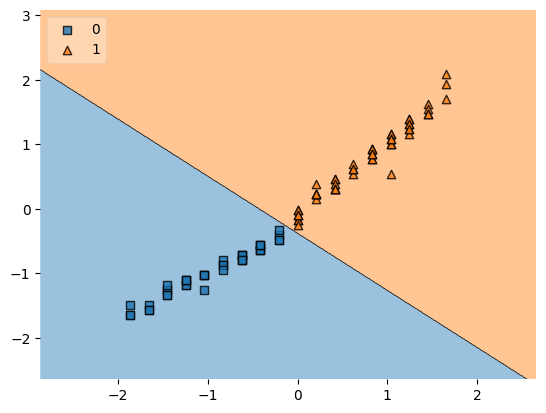

In [134]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(x_train, y_train.values, clf=model, legend=2)

In [135]:
import pickle


pickle.dump(model, open('model.pkl','wb'))